# The functional relation of $\alpha_\text{best}(p)$ in soft-evidence correlated matching

**Data:** `data/alpha_sweep_extended_fixed_MWPM.csv` — rotated surface-code memory-Z, circuit-level
depolarizing noise, generated by `scripts/test_alpha_decode.py`.

Each row is a decoder on a fixed common-random-number shot budget. For every $(d, p)$ we have:

* **MWPM** — plain min-weight perfect matching (`enable_correlations=False`), the baseline.
* **CM($\alpha$)** — Pearl *soft-evidence* correlated matching. For each decoding edge $\mu$ the first
  MWPM pass supplies evidence $\nu$ = "$\mu$'s correlated partner fired." Here $\alpha$ is the
  *confidence that this evidence is real*, and **Pearl's soft-evidence rule** sets the edge's improved
  firing probability to
  $$p^{\rm imp} \;=\; \alpha\,P(\mu\mid\nu)\;+\;(1-\alpha)\,P(\mu\mid\lnot\nu),
  \qquad w^{\rm imp}=\log\frac{1-p^{\rm imp}}{p^{\rm imp}},$$
  with the two conditionals read from DEM co-occurrence statistics,
  $P(\mu\mid\nu)=\text{corr}/\text{occ}_\nu$ and
  $P(\mu\mid\lnot\nu)=(\text{occ}_\mu-\text{corr})/(1-\text{occ}_\nu)$; the decoder keeps the most-reduced
  weight over a node's fired partners. Note the mixing is **linear in probability, not in weight.**
  * $\alpha = 0 \Rightarrow p^{\rm imp}=P(\mu\mid\lnot\nu)\approx$ marginal $\Rightarrow$ essentially MWPM.
  * $\alpha = 1 \Rightarrow p^{\rm imp}=P(\mu\mid\nu)$ — ordinary (full-strength) correlated matching.

**Two questions this notebook addresses**

1. **What is $\alpha_\text{best}(p)$?** — the confidence that minimises LER. Empirically it *rises*
   monotonically with $p$ and heads toward $0$ as $p \to 0$.
2. **Why does full CM ($\alpha=1$) lose to MWPM at low $p$, and why must the multiplier shrink as
   $p$ decreases?** — we develop a log-odds / dominant-failure-chain mechanism and back it with a
   transparent Bayesian toy model.

Everything below is derived from the CSV plus a phenomenological toy — no Stim / PyMatching needed.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "axes.axisbelow": True, "figure.autolayout": True,
})

# Robustly locate the CSV whether the notebook runs from repo root or notebooks/.
CANDIDATES = [
    "data/alpha_sweep_extended_fixed_MWPM.csv",
    "../data/alpha_sweep_extended_fixed_MWPM.csv",
]
CSV = next((c for c in CANDIDATES if os.path.exists(c)), CANDIDATES[0])
df = pd.read_csv(CSV)
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")   # blank for mwpm -> NaN
print("loaded", CSV, "|", len(df), "rows")
print("distances:", sorted(df.distance.unique()))
print("alphas    :", sorted(df.loc[df.decoder=='cm','alpha'].unique()))
df.head()

loaded ../data/alpha_sweep_extended_fixed_MWPM.csv | 195 rows
distances: [np.int64(5), np.int64(7)]
alphas    : [np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]


,distance,rounds,p,decoder,alpha,shots,errors,ler,ler_std
0,5,5,0.0001,mwpm,NaN,2980000000,410,1.375839e-07,6.794784e-09
1,5,5,0.0001,cm,0.05,2980000000,251,8.422819e-08,5.316436e-09
2,5,5,0.0001,cm,0.10,2980000000,236,7.919463e-08,5.155131e-09
3,5,5,0.0001,cm,0.15,2980000000,238,7.986577e-08,5.176929e-09
4,5,5,0.0001,cm,0.20,2980000000,248,8.322148e-08,5.284569e-09


## 1. Pivot the sweep and confirm the two phenomena

For each $(d,p)$ we pull the MWPM baseline, the full-CM ($\alpha=1$) point, and the discrete
$\arg\min_\alpha$ LER. Because LER is measured as an error *count* over a fixed shot budget,
each entry carries binomial (Poisson-like) noise — we keep `errors` and `shots` so we can propagate
that uncertainty later.

In [2]:
cm = df[df.decoder == "cm"].copy()
mw = df[df.decoder == "mwpm"].set_index(["distance", "p"])["errors"]

rows = []
for (d, p), g in cm.groupby(["distance", "p"]):
    g = g.sort_values("alpha")
    shots = g["shots"].iloc[0]
    e_mw = int(mw.loc[(d, p)])
    e_a1 = int(g.loc[g.alpha == 1.0, "errors"].iloc[0])
    imin = g["errors"].idxmin()
    rows.append(dict(
        d=d, p=p, shots=int(shots), err_mwpm=e_mw, err_cm1=e_a1,
        alpha_argmin=float(g.loc[imin, "alpha"]), err_best=int(g.loc[imin, "errors"]),
        cm1_over_mwpm=e_a1 / e_mw, best_over_mwpm=g.loc[imin, "errors"] / e_mw,
    ))
summary = pd.DataFrame(rows).sort_values(["d", "p"]).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
summary

,d,p,shots,err_mwpm,err_cm1,alpha_argmin,err_best,cm1_over_mwpm,best_over_mwpm
0,5,0.0001,2980000000,410,502,0.1,236,1.224,0.5756
1,5,0.0002,520000000,549,500,0.2,288,0.9107,0.5246
2,5,0.0004,90000000,798,544,0.2,437,0.6817,0.5476
3,5,0.0007,20000000,920,582,0.4,509,0.6326,0.5533
4,5,0.001,10000000,1308,796,0.4,748,0.6086,0.5719
5,5,0.002,10000000,10038,6238,0.6,6024,0.6214,0.6001
6,5,0.004,10000000,74241,50601,0.8,50067,0.6816,0.6744
7,5,0.007,10000000,339818,264531,0.7,262957,0.7784,0.7738
8,5,0.01,10000000,815174,695312,0.7,690878,0.853,0.8475
9,7,0.0007,320000000,1304,505,0.4,418,0.3873,0.3206


Two things stand out already:

* **`alpha_argmin` climbs with $p$** (from $\sim0.1$ at $p=10^{-4}$ to $\sim0.7$–$0.8$ at
  $p=10^{-2}$).
* **`cm1_over_mwpm` $> 1$ only at the lowest $p$ / smallest $d$** (d=5, $p=10^{-4}$: full CM is
  $1.22\times$ *worse* than MWPM). Meanwhile **`best_over_mwpm` $< 1$ everywhere** — tuned CM never
  loses. So the effect is not "CM cannot help at low $p$"; it is "**untuned, full-strength CM
  overcorrects**, and the optimal confidence collapses toward zero."

The plot below makes the crossover explicit.

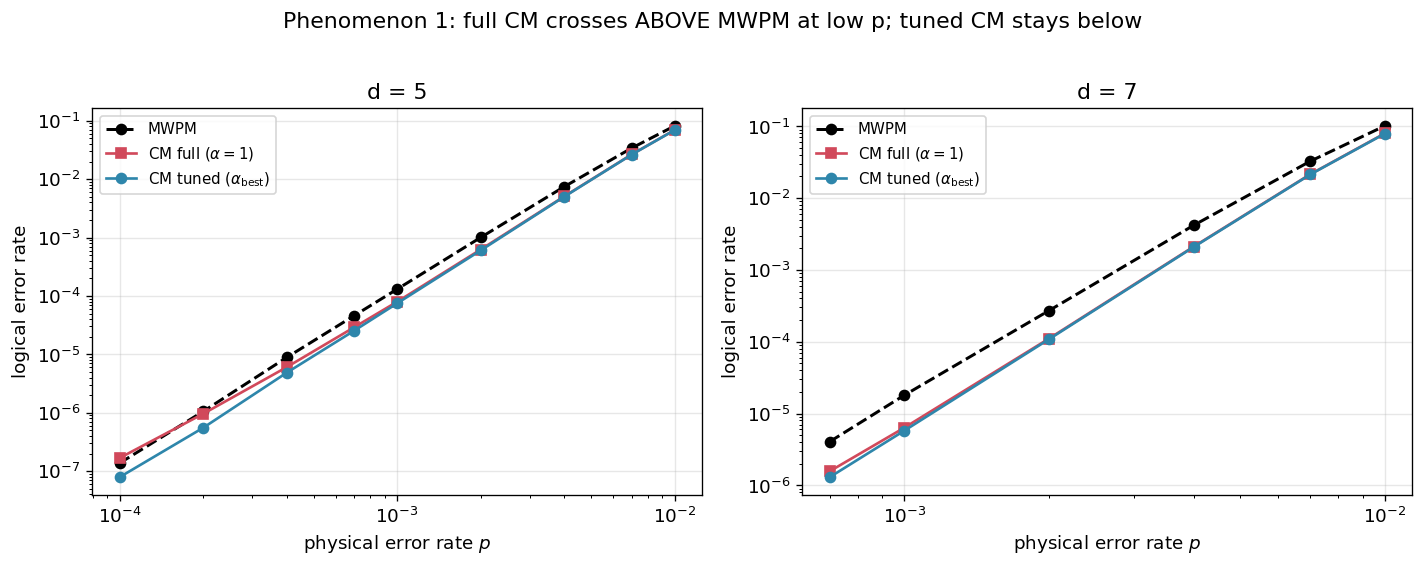

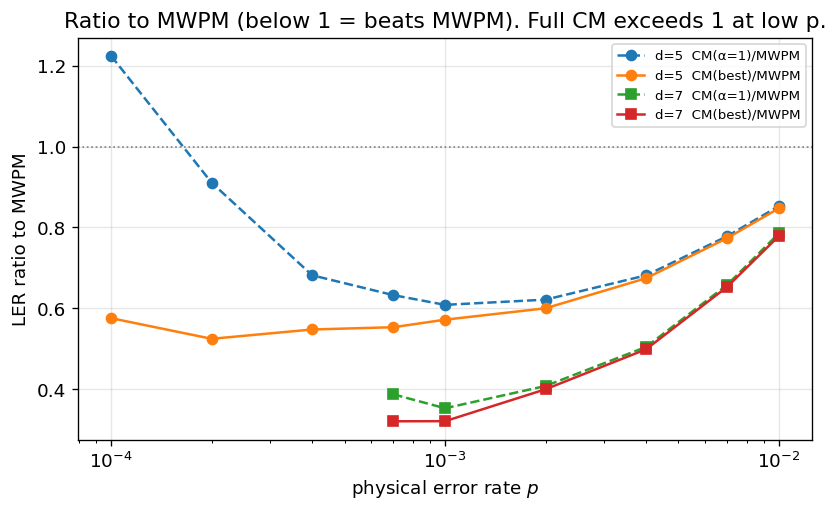

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=False)
for ax, d in zip(axes, sorted(summary.d.unique())):
    s = summary[summary.d == d]
    ax.loglog(s.p, s.err_mwpm / s.shots, "k--o", lw=1.8, ms=6, label="MWPM")
    ax.loglog(s.p, s.err_cm1 / s.shots, "-s", color="#d1495b", lw=1.6, ms=6,
              label=r"CM full ($\alpha=1$)")
    ax.loglog(s.p, s.err_best / s.shots, "-o", color="#2e86ab", lw=1.6, ms=6,
              label=r"CM tuned ($\alpha_\mathrm{best}$)")
    ax.set(xlabel="physical error rate $p$", ylabel="logical error rate", title=f"d = {d}")
    ax.legend(fontsize=9)
fig.suptitle("Phenomenon 1: full CM crosses ABOVE MWPM at low p; tuned CM stays below", y=1.02)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.4))
for d, mk in zip(sorted(summary.d.unique()), ["o", "s"]):
    s = summary[summary.d == d]
    ax.semilogx(s.p, s.cm1_over_mwpm, "--"+mk, label=f"d={d}  CM(α=1)/MWPM")
    ax.semilogx(s.p, s.best_over_mwpm, "-"+mk, label=f"d={d}  CM(best)/MWPM")
ax.axhline(1.0, color="gray", lw=1, ls=":")
ax.set(xlabel="physical error rate $p$", ylabel="LER ratio to MWPM",
       title="Ratio to MWPM (below 1 = beats MWPM). Full CM exceeds 1 at low p.")
ax.legend(fontsize=8)
plt.show()

## 2. Extracting $\alpha_\text{best}$ with its uncertainty

At low $p$ the error counts are only a few hundred, so adjacent-$\alpha$ differences (e.g. 236 vs
238 vs 248) are within counting noise and the raw `argmin` is jittery. We therefore fit a
**weighted parabola to $\log(\text{errors})$ vs $\alpha$** in a window around the discrete minimum
and take the vertex as a continuous $\alpha_\text{best}$. Uncertainty comes from a **binomial
bootstrap**: resample each point's error count as $\text{Binomial}(\text{shots}, \text{LER})$,
refit, and take the 16–84 percentile band of the vertex.

In [4]:
def parabola_vertex(alphas, errs, shots, window=2):
    # Weighted quadratic fit of log(errors) vs alpha near the argmin -> vertex alpha*.
    alphas = np.asarray(alphas, float); errs = np.asarray(errs, float)
    k = int(np.argmin(errs))
    lo, hi = max(0, k - window), min(len(alphas), k + window + 1)
    if hi - lo < 3:                      # widen at the grid edges
        lo, hi = max(0, hi - 3), min(len(alphas), lo + 3)
    x, y = alphas[lo:hi], np.log(np.maximum(errs[lo:hi], 1.0))
    w = np.maximum(errs[lo:hi], 1.0)     # var(log N) ~ 1/N  ->  weight ~ N
    a2, a1, a0 = np.polyfit(x, y, 2, w=np.sqrt(w))
    if a2 <= 0:                          # not convex -> fall back to discrete argmin
        return float(alphas[k])
    return float(np.clip(-a1 / (2 * a2), alphas.min(), alphas.max()))

def alpha_best_with_ci(g, n_boot=800, seed=0):
    g = g.sort_values("alpha")
    a = g["alpha"].to_numpy(); e = g["errors"].to_numpy(float); n = g["shots"].to_numpy(float)
    point = parabola_vertex(a, e, n)
    rng = np.random.default_rng(seed)
    ler = e / n
    boot = [parabola_vertex(a, rng.binomial(n.astype(int), ler).astype(float), n)
            for _ in range(n_boot)]
    lo, hi = np.percentile(boot, [16, 84])
    # keep the point estimate inside the band so error-bar lengths stay non-negative
    return point, min(lo, point), max(hi, point)

recs = []
for (d, p), g in cm.groupby(["distance", "p"]):
    pt, lo, hi = alpha_best_with_ci(g)
    recs.append(dict(d=d, p=p, alpha_best=pt, lo=lo, hi=hi))
ab = pd.DataFrame(recs).sort_values(["d", "p"]).reset_index(drop=True)
ab

,d,p,alpha_best,lo,hi
0,5,0.0001,0.1277,0.05,0.1737
1,5,0.0002,0.05,0.05,0.2338
2,5,0.0004,0.2795,0.2141,0.3799
3,5,0.0007,0.4149,0.3323,0.5078
4,5,0.001,0.474,0.4175,0.7497
5,5,0.002,0.5966,0.522,0.7
6,5,0.004,0.7649,0.7222,0.8128
7,5,0.007,0.7682,0.7384,0.7995
8,5,0.01,0.7304,0.6896,0.7516
9,7,0.0007,0.4091,0.3458,0.4768


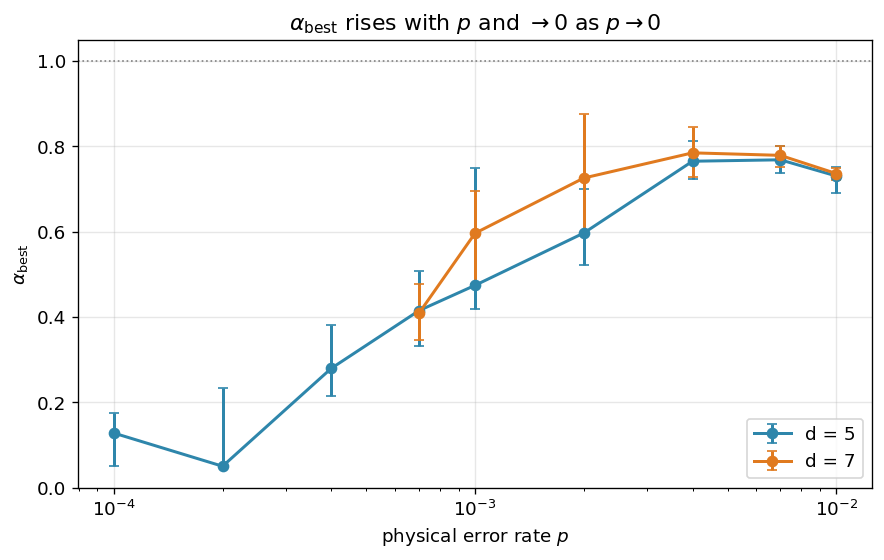

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
colors = {5: "#2e86ab", 7: "#e07a1f"}
for d in sorted(ab.d.unique()):
    s = ab[ab.d == d]
    ax.errorbar(s.p, s.alpha_best,
                yerr=[s.alpha_best - s.lo, s.hi - s.alpha_best],
                fmt="o-", color=colors.get(d, None), capsize=3, lw=1.8, ms=6,
                label=f"d = {d}")
ax.set_xscale("log")
ax.set(xlabel="physical error rate $p$", ylabel=r"$\alpha_\mathrm{best}$",
       ylim=(0, 1.05),
       title=r"$\alpha_\mathrm{best}$ rises with $p$ and $\to 0$ as $p \to 0$")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.legend()
plt.show()

## 3. Candidate functional forms for $\alpha_\text{best}(p)$

We test three shapes suggested by the mechanism (Section 5):

| form | expression | rationale |
|------|-----------|-----------|
| **log-linear** | $\alpha = a\,\log_{10}p + b$ | the applied log-odds shift scales with the edge weight $\sim -\log p$ |
| **power law**  | $\alpha = A\,p^{\,k}$ | scale-free benefit/harm frequency ratio |
| **saturating** | $\alpha = \dfrac{L}{1+(p_0/p)^{m}}$ | $\to 0$ at low $p$, plateaus at the CM optimum ($\sim0.7$–$0.8$) at high $p$ |

Fits are weighted by the bootstrap uncertainty from Section 2. We fit $d=5$ (the widest $p$ span)
and overlay $d=7$.

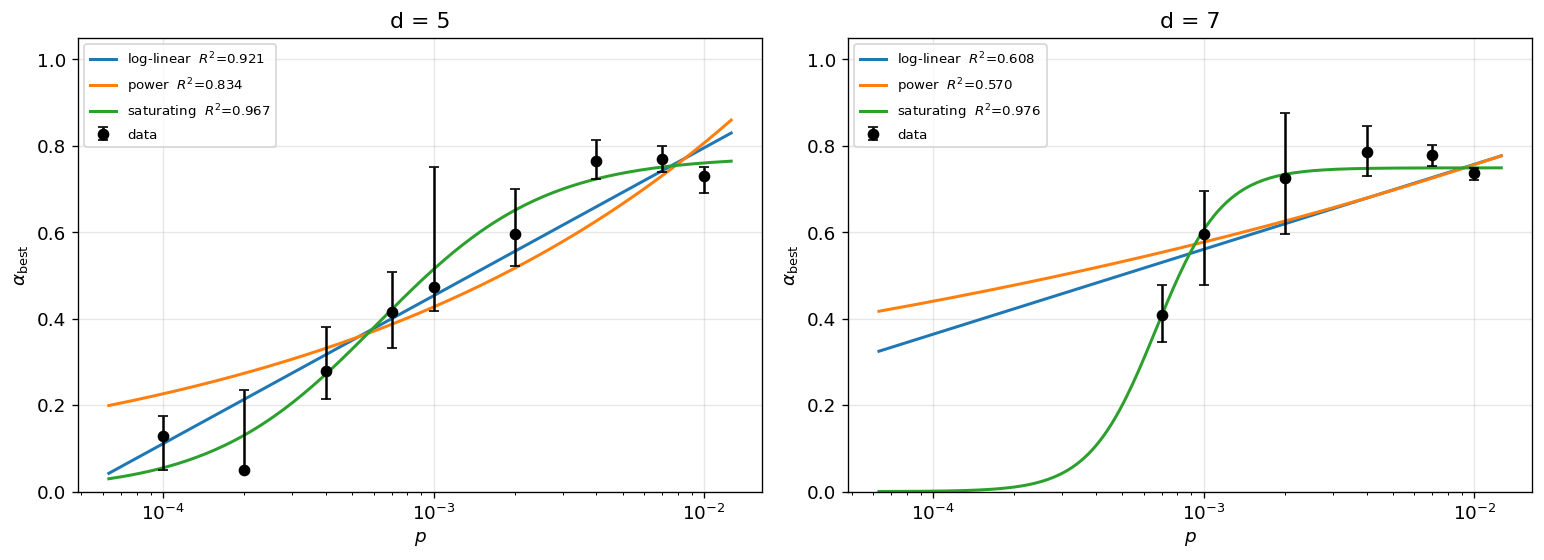

Fitted parameters:

 d=5
  log-linear  params=[0.3422, 1.4796]  R2=0.9209
  power       params=[2.8766, 0.2762]  R2=0.8342
  saturating  params=[0.775, 0.0006, 1.4123]  R2=0.9673

 d=7
  log-linear  params=[0.1965, 1.1498]  R2=0.6080
  power       params=[1.2982, 0.1174]  R2=0.5699
  saturating  params=[0.7488, 0.0007, 3.5324]  R2=0.9755


In [6]:
def r2(y, yhat, w=None):
    w = np.ones_like(y) if w is None else w
    ybar = np.average(y, weights=w)
    ss_res = np.sum(w * (y - yhat) ** 2)
    ss_tot = np.sum(w * (y - ybar) ** 2)
    return 1 - ss_res / ss_tot

def f_loglin(p, a, b):   return a * np.log10(p) + b
def f_power(p, A, k):    return A * np.power(p, k)
def f_sat(p, L, p0, m):  return L / (1 + (p0 / p) ** m)

fits = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
p_grid = np.logspace(-4.2, -1.9, 200)
for ax, d in zip(axes, sorted(ab.d.unique())):
    s = ab[ab.d == d].sort_values("p")
    p = s.p.to_numpy(); y = s.alpha_best.to_numpy()
    sig = np.maximum((s.hi.to_numpy() - s.lo.to_numpy()) / 2, 1e-3)
    ax.errorbar(p, y, yerr=[y - s.lo, s.hi - y], fmt="ko", capsize=3, ms=6, label="data", zorder=5)

    res = {}
    try:
        pc, _ = curve_fit(f_loglin, p, y, sigma=sig, absolute_sigma=False)
        res["log-linear"] = (pc, f_loglin, r2(y, f_loglin(p, *pc)))
    except Exception as ex: print(d, "loglin", ex)
    try:
        pc, _ = curve_fit(f_power, p, y, p0=[3, 0.4], sigma=sig, maxfev=10000)
        res["power"] = (pc, f_power, r2(y, f_power(p, *pc)))
    except Exception as ex: print(d, "power", ex)
    try:
        pc, _ = curve_fit(f_sat, p, y, p0=[0.8, 1e-3, 1.0],
                          bounds=([0.3, 1e-5, 0.2], [1.2, 1e-1, 4]), sigma=sig, maxfev=20000)
        res["saturating"] = (pc, f_sat, r2(y, f_sat(p, *pc)))
    except Exception as ex: print(d, "sat", ex)
    fits[d] = res

    for name, (pc, f, r2v) in res.items():
        ax.plot(p_grid, np.clip(f(p_grid, *pc), 0, 1.2), lw=1.8,
                label=f"{name}  $R^2$={r2v:.3f}")
    ax.set_xscale("log")
    ax.set(xlabel="$p$", ylabel=r"$\alpha_\mathrm{best}$", ylim=(0, 1.05), title=f"d = {d}")
    ax.legend(fontsize=8)
plt.show()

print("Fitted parameters:")
for d, res in fits.items():
    print(f"\n d={d}")
    for name, (pc, f, r2v) in res.items():
        print(f"  {name:11s} params={np.round(pc, 4).tolist()}  R2={r2v:.4f}")

**Reading the fits.** All three capture the monotone rise, but they say different things about
the $p\to0$ limit:

* the **power law** ($\alpha \approx A\,p^{k}$, $k \sim 0.3$–$0.5$) and the **saturating** form both
  send $\alpha_\text{best}\to 0$ as $p\to 0$ — consistent with "the correction must be switched off
  in the low-$p$ limit";
* the **log-linear** form is the simplest good description over the *measured* window but would
  (unphysically) cross zero at finite $p$, so treat it as a local approximation only.

Given only 6–9 $p$-points per distance and bootstrap-level scatter, we do **not** over-claim a
unique law; the robust, model-independent statement is **monotone increasing, concave in $\log p$,
$\to 0$ as $p\to 0$, saturating below the CM optimum ($\approx 0.7$–$0.8$) at high $p$.**

## 4. Shape of the LER–$\alpha$ curve: how sharp is the optimum?

The *cost of mis-tuning* $\alpha$ tells us how strong the competing forces are. We plot
$\text{LER}(\alpha)/\text{LER}(\alpha{=}1)$ per $(d,p)$ (as in the generating script) and also read
off the curvature at the minimum from the Section-2 parabola.

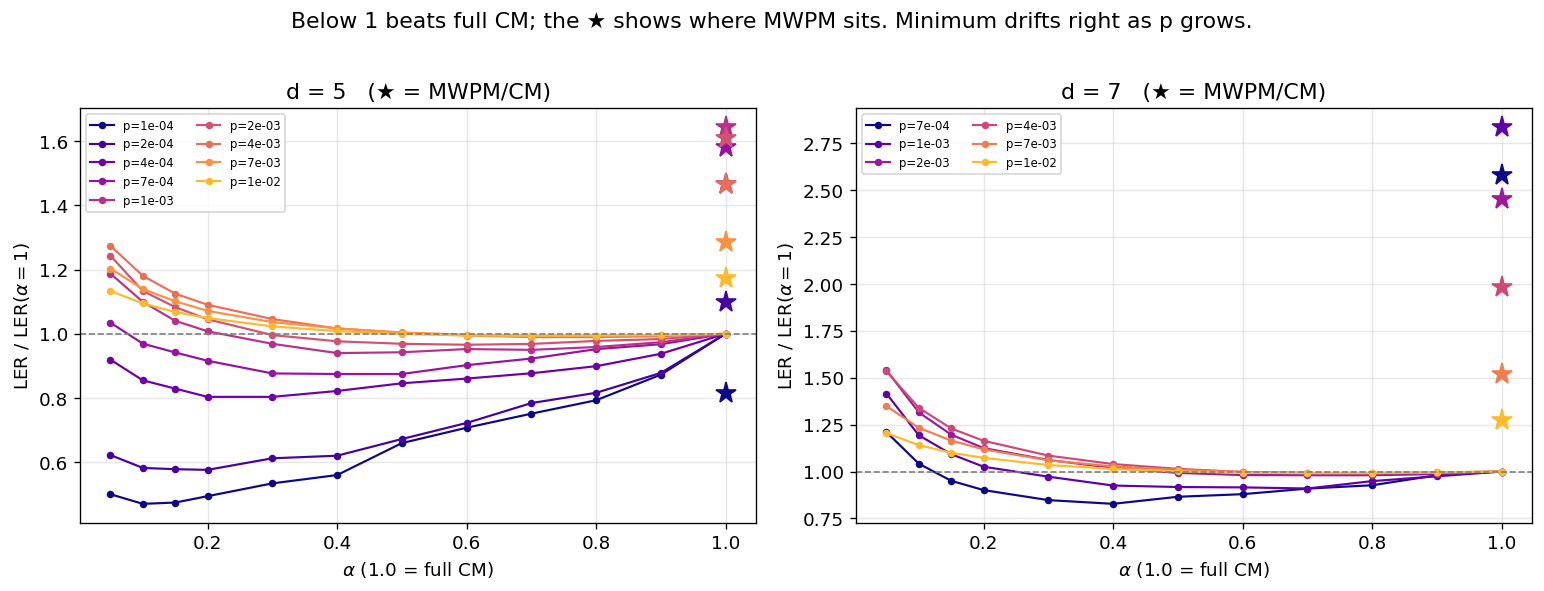

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, d in zip(axes, sorted(cm.distance.unique())):
    ps = sorted(cm[cm.distance == d].p.unique())
    cols = plt.cm.plasma(np.linspace(0, 0.85, len(ps)))
    for p, c in zip(ps, cols):
        g = cm[(cm.distance == d) & (cm.p == p)].sort_values("alpha")
        base = g.loc[g.alpha == 1.0, "errors"].iloc[0]
        ax.plot(g.alpha, g.errors / base, "-o", color=c, ms=3.5, lw=1.3, label=f"p={p:.0e}")
        ax.plot([1.0], [mw.loc[(d, p)] / base], "*", color=c, ms=13)  # MWPM ref (star at a=1)
    ax.axhline(1.0, color="gray", ls="--", lw=1)
    ax.set(xlabel=r"$\alpha$ (1.0 = full CM)", ylabel=r"LER / LER($\alpha{=}1$)",
           title=f"d = {d}   (★ = MWPM/CM)")
    ax.legend(fontsize=7, ncol=2)
fig.suptitle("Below 1 beats full CM; the ★ shows where MWPM sits. Minimum drifts right as p grows.",
             y=1.02)
plt.show()

The minimum of each curve slides from the far left (small $\alpha$) at low $p$ toward the right
(large $\alpha$) at high $p$ — the same message as Section 2, now visible as a *shape* change. At the
lowest $p$ the star (MWPM) sits *below 1*, i.e. MWPM beats full CM, and the useful region is a narrow
sliver at small $\alpha$.

## 5. Proposed mechanism

**Setup — and one thing the depolarizing model rules out.** Correlated matching couples the two
syndrome graphs (X-type and Z-type detectors) through faults that fire detectors in *both*. Those are
exactly the faults with both an $X$- and a $Z$-type signature: **single-qubit $Y$ errors**, and the
**mixed two-qubit depolarizing errors on the CNOTs** — every two-qubit Pauli *except* $XX$ and $ZZ$
(which stay inside a single graph). Note **hook errors do *not* create these cross-graph correlations**:
a hook is a weight-2 error within *one* sector (a diagonal edge in a single graph), not a coupling
between graphs. Under depolarizing noise $X,Y,Z$ are **equally likely**, and that kills the naive
"low-$p$ story":

* the correlated events CM exploits ($Y$ and mixed two-qubit errors) are single faults of rate $\sim p$
  — **no rarer than the $X$/$Z$ errors** that make up the bulk chains. A minimal-weight logical-$Z$
  failure chain routinely contains $Y$ (and CNOT-correlated) faults, so the correction is relevant at
  every $p$; it is **not** the case that low-$p$ failures are "clean chains with no correlation."
* but a firing in the conditioning graph comes from a non-correlating fault (e.g. a pure $Z$) about as
  often as from a correlating one, so the shared-fault posterior
  $P(\mu\mid\nu)=\text{corr}/\text{occ}_\nu=\mathcal{O}(1)$ is a **bounded fraction, essentially
  independent of $p$**. The evidence is informative but never certain — at *any* $p$.

So neither "$Y$ becomes rare" nor "reliability changes with $p$" can explain $\alpha_\text{best}(p)$.
The real driver is a **broken scale invariance.**

**Everything in a matching problem scales like $|\log p|$ — except the boosted edge.** Bulk edge
weights are $w\sim-\log p_e\sim|\log p|$, so a uniform rescaling of $p$ leaves the matching — and any
*dimensionless* $\alpha$ — unchanged. The correlation conditional breaks that symmetry: at strength
$\alpha$, Pearl sets $p^{\rm imp}\approx\alpha\,P(\mu\mid\nu)$ (the $(1-\alpha)P(\mu\mid\lnot\nu)=O(p)$
term is decode-irrelevant at low $p$, as `pearl_vs_damped_grid.ipynb` measures), so the boosted edge's
weight is
$$w^{\rm imp}(\alpha)\;=\;-\log\!\big(\alpha\,P(\mu\mid\nu)\big)\;\approx\;|\log\alpha|+\mathcal{O}(1),$$
which does **not** grow with $|\log p|$. As $p\to0$ the boosted edge becomes *nearly free relative to
the ambient $|\log p|$ scale*, so the second pass routes through it almost unconditionally — including
on the $\mathcal{O}(1)$ fraction of boosts that are spurious ($Z$ mimicking $Y$). That is the
overcorrection.

**Why $\alpha_\text{best}$ falls as $p\to0$.** To keep the boosted edge a *controlled fraction* of the
ambient scale — so the matching still weighs it against alternatives instead of treating it as free —
its weight $|\log\alpha|+\mathcal{O}(1)$ must track $|\log p|$, i.e. $\alpha$ must scale **down** with
$p$: a power law $\alpha_\text{best}\sim p^{\,c}$, consistent with the $A\,p^{k}$ fit ($k\!\sim\!0.3$).
Equivalently, in the near-degenerate minimal-weight matchings that dominate the low-$p$ LER: a
*correct* boost only needs to tip the decision the right way (benefit **saturates**), whereas a
*spurious* boost's damage keeps growing once the boosted edge is effectively free (**unbounded harm**).
Bounded benefit vs unbounded harm forces a finite, $p$-shrinking optimum, and pushes full CM
($\alpha=1$) *below* MWPM at the lowest $p$ ($d=5,\,p=10^{-4}$).

**Why it rises toward threshold.** Near threshold $|\log p|\sim\mathcal{O}(1)$, so even $\alpha=1$
keeps the boosted edge comparable to alternatives (no runaway); chains lengthen and carry more genuine
multi-fault correlation; $\alpha_\text{best}$ climbs toward the intrinsic CM plateau
($\approx0.7$–$0.8$, where full CM is itself only a heuristic). This is the monotone,
concave-in-$\log p$, saturating curve of Sections 2–3.

**An honest caveat.** A strict *per-edge* Bayesian reading would call $\alpha=1$ optimal (it sets
$p^{\rm imp}$ to the exact conditional $P(\mu\mid\nu)$). The observed need to damp — and full CM
*losing* to MWPM — must therefore come from the **non-Bayesian two-pass greedy structure**:
hard-committing to an uncertain first pass and applying pairwise boosts independently, whose errors are
amplified exactly where the low-$p$ LER lives. The scale-invariance argument fixes the *direction and
$p$-scaling* of $\alpha_\text{best}$; a first-principles constant is beyond what this CSV can settle.

## 6. An illustrative cartoon of the scale-invariance mechanism

A single shared $\alpha$ is applied to *many* boosts per shot. Split them into two classes and let each
compete against its correct alternative, whose cost rides the ambient $\sim|\log_{10}p|$ scale:

* **genuine** ($Y$-partner real): the correct alternative is *expensive* ($a_g|\log_{10}p|$), so a
  genuine boost gets used as soon as the boosted edge is modestly cheap (**low $\alpha$ suffices**);
  using it *removes* an error → benefit $B$.
* **spurious** ($Z$ mimicking $Y$): the correct alternative is *cheap* ($a_s|\log_{10}p|$, $a_s<a_g$),
  so the boosted edge over-rides it only once it is *very* cheap (**high $\alpha$**); using it
  *creates* an error → harm $H$.

The boosted-edge cost $c(\alpha)=-\log_{10}(\alpha\,q)$ is **pinned** (broken scale invariance) while
both alternatives grow with $|\log_{10}p|$. With
$P_\text{use}^{\,\cdot}=\Phi\!\big((a_\cdot|\log_{10}p|-c(\alpha))/s\big)$,
$$E(\alpha)\;=\;-\,B\,P_\text{use}^{\text{genuine}}\;+\;H\,P_\text{use}^{\text{spurious}} .$$
This is a **phenomenological cartoon with hand-chosen constants** — not a fit and not a derivation —
included only to show the two observed features fall out of the pinned-cost picture.

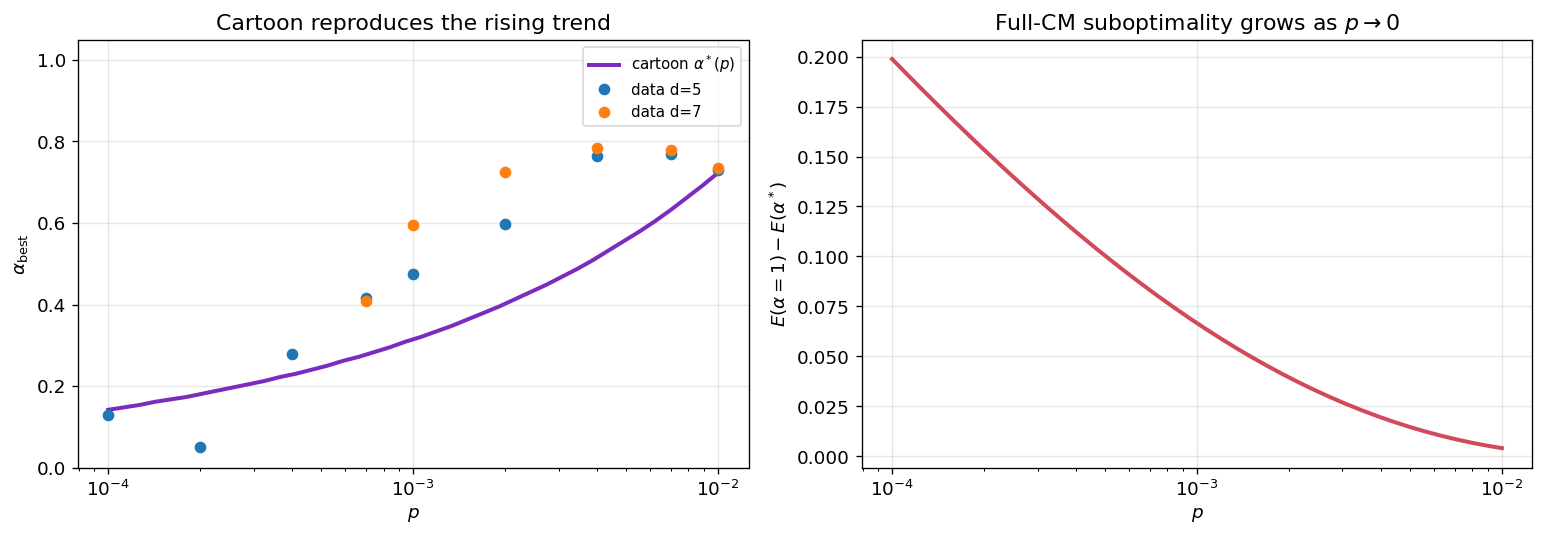

cartoon alpha* at data-like p: {'1e-04': 0.14, '1e-03': 0.31, '1e-02': 0.72}


In [8]:
from scipy.stats import norm

def toy_E(alpha, L, q=0.4, B=1.2, H=1.1, a_g=0.45, a_s=0.2, s=0.8):
    c = -np.log10(np.clip(alpha, 1e-6, 1.0) * q)          # pinned boosted-edge cost
    use_g = norm.cdf((a_g * L - c) / s)                    # P(route through boost | genuine)
    use_s = norm.cdf((a_s * L - c) / s)                    # P(route through boost | spurious)
    return -B * use_g + H * use_s                          # E relative to MWPM (alpha->0 => 0)

grid = np.linspace(0.02, 1.0, 500)
pp = np.logspace(-4, -2, 40)
astar = np.array([grid[np.argmin([toy_E(a, -np.log10(p)) for a in grid])] for p in pp])
subopt = np.array([toy_E(1.0, -np.log10(p)) - min(toy_E(a, -np.log10(p)) for a in grid) for p in pp])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.semilogx(pp, astar, "-", color="#7b2cbf", lw=2.4, label=r"cartoon $\alpha^*(p)$")
for d in sorted(ab.d.unique()):
    s = ab[ab.d == d]
    ax.semilogx(s.p, s.alpha_best, "o", ms=6, label=f"data d={d}")
ax.set(xlabel="$p$", ylabel=r"$\alpha_\mathrm{best}$", ylim=(0, 1.05),
       title="Cartoon reproduces the rising trend")
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogx(pp, subopt, "-", color="#d1495b", lw=2.4)
ax.set(xlabel="$p$", ylabel=r"$E(\alpha{=}1) - E(\alpha^*)$",
       title="Full-CM suboptimality grows as $p\\to0$")
plt.show()
print("cartoon alpha* at data-like p:",
      {f"{p:.0e}": round(float(grid[np.argmin([toy_E(a, -np.log10(p)) for a in grid])]), 2)
       for p in (1e-4, 1e-3, 1e-2)})

**What the cartoon does and doesn't show.** With the pinned boosted-edge cost $c(\alpha)$ and
both alternatives riding $|\log_{10}p|$, the minimiser $\alpha^*(p)$ *rises with $p$* — closely
tracking $d=5$ — and full CM ($\alpha=1$) becomes *increasingly suboptimal as $p\to0$* (right panel).
That is the core asked-for behaviour. The stronger feature — $\alpha=1$ dipping *below* MWPM at the
very lowest $p$ — needs the additional non-Bayesian ingredients of Section 5 (hard first-pass
commitment, independent pairwise boosts) and is **not** forced by this two-class picture; the cartoon
is a direction-of-effect argument, nothing more.

## 7. Summary, predictions, and caveats

**What the data show**
* $\alpha_\text{best}(p)$ is **monotone increasing**, concave in $\log p$, tending to $0$ as
  $p\to0$ and saturating around $0.7$–$0.8$ at high $p$ (the intrinsic CM optimum).
* **Full-strength CM ($\alpha=1$) overcorrects at low $p$** and loses to MWPM (seen at $d=5$,
  $p=10^{-4}$: $1.22\times$ worse). *Tuned* CM beats MWPM at every $(d,p)$ measured.

**Mechanism** — *not* "$Y$ becomes rare" (depolarizing keeps $X,Y,Z$ equiprobable, so the shared-fault
posterior $P(\mu\mid\nu)=\mathcal{O}(1)$ is roughly $p$-independent). It is a **broken scale
invariance**: bulk edge weights scale as $|\log p|$, but Pearl pins the boosted edge at
$w^{\rm imp}\approx|\log\alpha|+\mathcal{O}(1)$. At $\alpha=1$ that edge is nearly *free* relative to
the ambient $|\log p|$ scale as $p\to0$, so the second pass routes through it even on the
$\mathcal{O}(1)$ fraction of spurious ($Z$-mimic) boosts — overcorrection. Keeping the boosted edge a
controlled fraction of $|\log p|$ forces $\alpha_\text{best}\sim p^{\,c}\to0$ (bounded benefit,
unbounded harm). A per-edge Bayesian view would keep $\alpha=1$; the damping is a property of the
non-Bayesian two-pass heuristic.

**Falsifiable predictions**
1. **Scaling.** The broken-scale-invariance picture predicts $\alpha_\text{best}\sim p^{\,c}$ with a
   $d$-dependent exponent; extending the sweep to lower $p$ and more distances
   (`test_alpha_decode.py --distances 3,5,7,9 --p-values 1e-4,7e-5,4e-5`) should keep $\alpha_\text{best}$
   falling (not plateauing) and let the $\alpha{=}1$-vs-MWPM crossover $p$ be located per $d$.
2. **Noise bias.** Because the driver is the pinned $\mathcal{O}(1)$ conditional (not rarity of the
   correlating faults), biased/dephasing noise that *changes the fraction of cross-graph correlators*
   ($Y$ and mixed two-qubit CNOT errors) should shift the plateau height and the reliability, but the
   low-$p$ *damping* (from the pinned cost vs the growing $|\log p|$ ambient) should persist — a clean
   test that separates "reliability" from "scale invariance."
3. **Adaptivity.** A decoder that scales the boosted-edge weight to a fixed fraction of the ambient
   $|\log p|$ (equivalently $\alpha\sim p^{\,c}$), or a learned per-shot gate, should recover the
   tuned-CM curve without a per-$p$ grid search — exactly the job the GNN-SAC policy is meant to do.

**Caveats** — only 6–9 $p$-points per distance; $\alpha_\text{best}$ at low $p$ is bootstrap-noisy; the
Section-6 cartoon is a direction-of-effect illustration, not a derivation, and a per-edge Bayesian
account would *not* predict damping at all (Section 5's caveat). The robust, model-independent claims
are the monotone $\alpha_\text{best}\to0$ trend and the low-$p$ overcorrection of full CM.